# Week 3 — Quantum Algorithms: Deutsch–Jozsa, Grover, and the QFT

**Quantum Artificial Intelligence**

---

With qubits, gates, entanglement, and measurement in hand, we can now build algorithms that do things
no classical computer can do as efficiently. This week covers the three pillars of the algorithmic
canon, each implemented from scratch on our state-vector simulator:

1. **The oracle model** and **Deutsch–Jozsa**, the first algorithm with a provable exponential
   separation — it decides a global property of a function in a *single* query.
2. **Grover's search**, which finds a marked item among $N$ in $O(\sqrt N)$ steps via amplitude
   amplification — a quadratic speedup with broad applications.
3. **The quantum Fourier transform (QFT)**, the engine behind Shor's algorithm and quantum phase
   estimation, and a recurring primitive throughout quantum computing.

The unifying theme is **interference**: quantum algorithms arrange amplitudes so that wrong answers
cancel and right answers reinforce. We will watch this happen numerically.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from functools import reduce

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

ket0 = np.array([1, 0], dtype=complex)
ket1 = np.array([0, 1], dtype=complex)
I2 = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
H = (1/np.sqrt(2)) * np.array([[1, 1], [1, -1]], dtype=complex)

def kron_all(ms): return reduce(np.kron, ms)
def Hn(n): return kron_all([H]*n)                       # Hadamard on all n qubits
def basis_state(bits):
    return kron_all([ket0 if b=='0' else ket1 for b in bits])


## 1. The oracle model and Deutsch–Jozsa

Many quantum algorithms are stated in terms of an **oracle**: a black-box unitary that computes some
function $f$ for us, and whose internal cost we don't count — we count *queries*. The question is how
many queries a quantum algorithm needs versus a classical one.

**Deutsch–Jozsa problem.** We are given $f:\{0,1\}^n \to \{0,1\}$ promised to be either **constant**
(same output for all inputs) or **balanced** (output $0$ on exactly half the inputs, $1$ on the other
half). Decide which. Classically, in the worst case you must check just over half the inputs —
$2^{n-1}+1$ queries — to be sure. The quantum algorithm needs **one**.

### 1.1 The phase oracle

We encode $f$ as a **phase oracle** $U_f$ that flips the sign of basis states where $f(x)=1$:

$$
U_f\,|x\rangle = (-1)^{f(x)}\,|x\rangle .
$$

(This is obtained from the standard reversible oracle by the "phase kickback" trick with an ancilla in
$|-\rangle$; we use the phase form directly for clarity.) The Deutsch–Jozsa circuit is then strikingly
simple: Hadamard all qubits, apply $U_f$, Hadamard again, and measure. If the result is the all-zeros
string, $f$ is constant; otherwise it is balanced.


In [2]:
def phase_oracle(fvals):
    # fvals: array of length 2^n with f(x) in {0,1}. Returns diagonal unitary (-1)^f(x).
    return np.diag((-1.0)**fvals).astype(complex)

def deutsch_jozsa(fvals):
    n = int(np.log2(len(fvals)))
    state = basis_state('0'*n)        # |0...0>
    state = Hn(n) @ state             # uniform superposition
    state = phase_oracle(fvals) @ state
    state = Hn(n) @ state
    probs = np.abs(state)**2
    p_all_zero = probs[0]
    verdict = "constant" if p_all_zero > 0.5 else "balanced"
    return verdict, p_all_zero

n = 3
# constant f (all zeros)
f_const = np.zeros(2**n, dtype=int)
# balanced f: first half 0, second half 1
f_bal = np.array([0]*(2**(n-1)) + [1]*(2**(n-1)))

for name, fv in [("constant", f_const), ("balanced", f_bal)]:
    verdict, p0 = deutsch_jozsa(fv)
    print(f"f is {name:9s} -> algorithm says '{verdict}'   (P(all-zero) = {p0:.3f})")
print("\nClassical worst case needs 2^(n-1)+1 =", 2**(n-1)+1, "queries; quantum needs 1.")


f is constant  -> algorithm says 'constant'   (P(all-zero) = 1.000)
f is balanced  -> algorithm says 'balanced'   (P(all-zero) = 0.000)

Classical worst case needs 2^(n-1)+1 = 5 queries; quantum needs 1.


One query suffices, exactly as promised: the measurement is all-zeros with certainty for constant
$f$ and never all-zeros for balanced $f$. The mechanism is interference — the final Hadamards make the
amplitudes of the all-zero outcome add up coherently only when $f$ is constant. Deutsch–Jozsa is
somewhat artificial, but it was the proof of concept that a quantum computer can be exponentially
faster, and it introduced the phase-kickback and interference patterns reused everywhere.

## 2. Grover's search

Grover's algorithm solves a far more practical problem: find a **marked** item in an unstructured
database of $N=2^n$ items. Classically this needs $O(N)$ queries (check items until you find it).
Grover finds it in $O(\sqrt N)$ — a **quadratic speedup** that applies to any brute-force search,
including many optimization and constraint-satisfaction problems.

### 2.1 Amplitude amplification

The idea is geometric. Start in the uniform superposition $|s\rangle$ over all items. Each **Grover
iteration** applies two reflections:

1. The **oracle** $U_w$ flips the sign of the marked item's amplitude (a reflection about the
   "unmarked" subspace).
2. The **diffusion operator** $U_s = 2|s\rangle\langle s| - I$ reflects all amplitudes about their
   mean.

The composition of two reflections is a **rotation**. Each iteration rotates the state vector a fixed
angle toward the marked item in a 2-D plane, so the marked amplitude grows roughly linearly with the
number of iterations — and after about $\tfrac{\pi}{4}\sqrt N$ iterations it is near $1$. We implement
it and watch the marked probability rise.


In [3]:
def grover(n, marked, n_iters=None):
    N = 2**n
    s = np.ones(N, dtype=complex) / np.sqrt(N)        # uniform superposition
    state = s.copy()
    # oracle: flip sign of marked index
    oracle = np.eye(N, dtype=complex); oracle[marked, marked] = -1
    # diffusion: 2|s><s| - I
    diffusion = 2*np.outer(s, s.conj()) - np.eye(N)
    if n_iters is None:
        n_iters = int(round(np.pi/4 * np.sqrt(N)))
    history = [np.abs(state[marked])**2]
    for _ in range(n_iters):
        state = oracle @ state
        state = diffusion @ state
        history.append(np.abs(state[marked])**2)
    return state, np.array(history), n_iters

n = 6                       # N = 64 items
marked = 42
state, history, n_iters = grover(n, marked)
probs = np.abs(state)**2
print(f"N = {2**n} items, marked = {marked}")
print(f"Grover iterations used: {n_iters}  (~ pi/4 * sqrt(N) = {np.pi/4*np.sqrt(2**n):.1f})")
print(f"P(marked) after Grover: {probs[marked]:.4f}")
print(f"P(any other single item): {probs[0]:.6f}")
print(f"\nClassical expected queries to find it: ~{2**n/2:.0f}; Grover: {n_iters}")


N = 64 items, marked = 42
Grover iterations used: 6  (~ pi/4 * sqrt(N) = 6.3)
P(marked) after Grover: 0.9966
P(any other single item): 0.000054

Classical expected queries to find it: ~32; Grover: 6


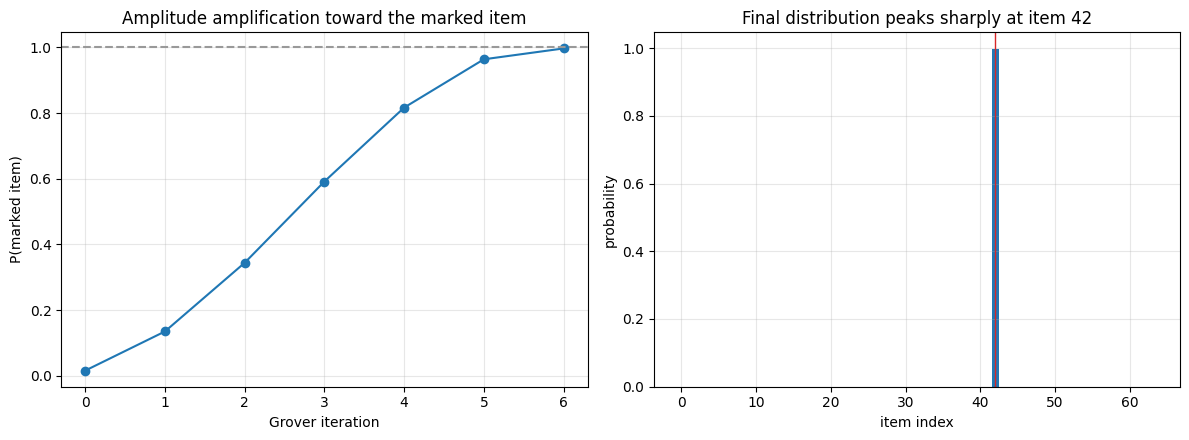

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.plot(range(len(history)), history, "o-")
ax1.axhline(1.0, color="0.6", ls="--")
ax1.set_xlabel("Grover iteration"); ax1.set_ylabel("P(marked item)")
ax1.set_title("Amplitude amplification toward the marked item")

ax2.bar(range(2**n), probs, width=1.0)
ax2.axvline(marked, color="C3", lw=1)
ax2.set_xlabel("item index"); ax2.set_ylabel("probability")
ax2.set_title(f"Final distribution peaks sharply at item {marked}")
plt.tight_layout(); plt.show()


The marked item's probability climbs to nearly $1$ after about $\tfrac{\pi}{4}\sqrt{N}\approx 6$
iterations, versus the $\sim32$ queries a classical search would need on average — the quadratic
speedup made visible. Note a quantum subtlety: if you keep iterating past the optimum, the probability
*overshoots and falls* (the rotation continues past the target), so knowing when to stop matters.

## 3. The quantum Fourier transform

The **quantum Fourier transform** is the quantum analogue of the discrete Fourier transform, and the
key subroutine of Shor's factoring algorithm and quantum phase estimation. On a basis state it acts as

$$
\text{QFT}\,|x\rangle = \frac{1}{\sqrt N}\sum_{k=0}^{N-1} e^{2\pi i\, x k / N}\,|k\rangle, \qquad N = 2^n .
$$

Its matrix is the familiar DFT matrix with entries $\omega^{xk}/\sqrt N$ where $\omega = e^{2\pi i/N}$.
What makes it *quantum*-useful is that it can be implemented with only $O(n^2)$ gates (Hadamards and
controlled phase rotations) instead of the $O(N\log N)$ operations of the classical FFT — an
exponential reduction in gate count, because the transform acts on amplitudes of an exponentially
large vector "in parallel." We build the QFT matrix directly and verify it is unitary and inverts the
computational basis into uniform-magnitude superpositions with the right phases.


In [5]:
def qft_matrix(n):
    N = 2**n
    omega = np.exp(2j*np.pi/N)
    j, k = np.meshgrid(np.arange(N), np.arange(N), indexing="ij")
    return omega**(j*k) / np.sqrt(N)

n = 3; N = 2**n
QFT = qft_matrix(n)
print("QFT is unitary:", np.allclose(QFT.conj().T @ QFT, np.eye(N)))

# QFT of |0> is the uniform superposition; QFT of |1> has linearly increasing phases.
for x in [0, 1]:
    psi = np.zeros(N, dtype=complex); psi[x] = 1
    out = QFT @ psi
    print(f"\nQFT|{x}>: magnitudes =", np.abs(out))
    print(f"          phases/pi  =", np.round(np.angle(out)/np.pi, 3))


QFT is unitary: True

QFT|0>: magnitudes = [0.3536 0.3536 0.3536 0.3536 0.3536 0.3536 0.3536 0.3536]
          phases/pi  = [0. 0. 0. 0. 0. 0. 0. 0.]

QFT|1>: magnitudes = [0.3536 0.3536 0.3536 0.3536 0.3536 0.3536 0.3536 0.3536]
          phases/pi  = [ 0.    0.25  0.5   0.75  1.   -0.75 -0.5  -0.25]


The QFT is unitary, maps $|0\rangle$ to the uniform superposition (all phases zero), and maps
$|1\rangle$ to a superposition whose phases wind linearly around the circle — the hallmark of a Fourier
basis. This phase structure is what phase estimation reads out to extract eigenvalues, the step that
gives Shor's algorithm its power.

### 3.1 QFT as a frequency detector

To make the QFT concrete, prepare a state whose amplitudes oscillate at a definite frequency and show
the QFT concentrates all probability on the corresponding frequency index — exactly like a classical
DFT identifying a pure tone.


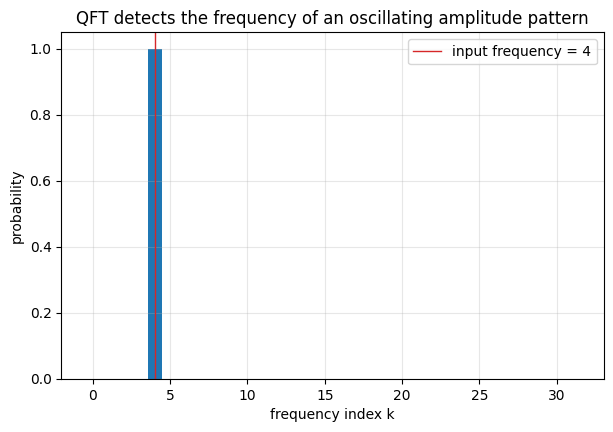

P(k=4) = 1.0000  (all probability concentrated at the true frequency)


In [6]:
n = 5; N = 2**n
QFT = qft_matrix(n)
freq = 4                                             # a pure "frequency" in the input
x = np.arange(N)
signal = np.exp(2j*np.pi*freq*x/N) / np.sqrt(N)     # amplitudes oscillating at `freq`

# Inverse QFT (= QFT^dagger) should localize this to index `freq`
spectrum = QFT.conj().T @ signal
probs = np.abs(spectrum)**2

plt.figure()
plt.bar(range(N), probs, width=0.9)
plt.axvline(freq, color="C3", lw=1, label=f"input frequency = {freq}")
plt.xlabel("frequency index k"); plt.ylabel("probability")
plt.title("QFT detects the frequency of an oscillating amplitude pattern")
plt.legend(); plt.show()
print(f"P(k={freq}) = {probs[freq]:.4f}  (all probability concentrated at the true frequency)")


The QFT places essentially all the probability on the single index matching the input frequency —
it is a frequency detector acting on quantum amplitudes. In phase estimation, the "frequency" encodes
the eigenphase of a unitary, and this concentration is what lets a quantum computer read eigenvalues
to many bits of precision. The same primitive, applied to the periodic state produced by modular
exponentiation, is the heart of Shor's algorithm for factoring.

## 4. Summary

- The **oracle/query model** counts black-box calls; **Deutsch–Jozsa** decides constant-vs-balanced in
  a single query by arranging interference so the all-zero outcome reveals the answer.
- **Grover's search** uses **amplitude amplification** — two reflections per iteration, a rotation
  toward the marked state — to search $N$ items in $O(\sqrt N)$ steps, a quadratic speedup; over-
  iterating overshoots the target.
- The **quantum Fourier transform** maps computational basis states to phase-structured superpositions,
  is implementable in $O(n^2)$ gates, and acts as a frequency detector; it underlies phase estimation
  and Shor's algorithm.

These algorithms exploit interference and superposition over an exponential space. In Week 4 we turn to
**variational** quantum circuits — parameterized, trainable circuits optimized by gradient descent —
and make the bridge from our NumPy simulator to PennyLane.


## 5. Exercises

**Exercise 1 (Deutsch–Jozsa scaling).** Run the algorithm for $n=2,\dots,8$ with random balanced and
constant functions and confirm it is always correct with one query. Construct a balanced $f$ that would
be expensive for a classical algorithm (agrees with "constant" on the first $2^{n-1}$ inputs).

**Exercise 2 (Grover overshoot).** For $N=64$, plot $P(\text{marked})$ against iteration count out to
$3\sqrt N$ iterations and identify where it peaks and where it returns near zero. Explain via the
rotation picture.

**Exercise 3 (multiple marked items).** Modify the Grover oracle to mark $m$ items. Show the optimal
iteration count becomes $\tfrac{\pi}{4}\sqrt{N/m}$ and verify numerically for $m=4$.

**Exercise 4 (QFT circuit).** Implement the QFT as an actual gate sequence (Hadamards and controlled
phase gates $R_k = \mathrm{diag}(1, e^{2\pi i/2^k})$) for $n=3$ and confirm it equals the QFT matrix up
to the final qubit-reversal swaps.


In [7]:
# Scratch space for the exercises.
